# Diagnostic Performance Evaluation of Simulated AI DR Screening Tools

This notebook evaluates the diagnostic accuracy of three simulated AI tools for
detecting referable diabetic retinopathy (DR). We compute standard metrics used
in diagnostic test evaluation — sensitivity, specificity, positive and negative
predictive values, ROC curves, calibration, and optimal operating points.

The AI tool profiles are based on published clinical trial data:
- **Tool A** (high-sensitivity autonomous AI): Khan et al. (2025) meta-analysis of IDx-DR
- **Tool B** (pivotal trial AI): Abramoff et al. (2018) IDx-DR FDA trial
- **Tool C** (semi-automated NZ AI): Vaghefi et al. (2023) THEIA prospective trial

This analysis uses the **equal performance** scenario (no subgroup variation)
to establish baseline accuracy. Equity-stratified analysis follows in Notebook 3.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.metrics import (
    diagnostic_accuracy,
    roc_analysis,
    precision_recall_analysis,
    calibration_analysis,
    optimal_threshold,
)
from src.visualisation import set_style, plot_roc_curves, plot_calibration

set_style()
%matplotlib inline

## 1. Load Simulated Data

In [2]:
# Load the equal-performance predictions for each tool
tools = {
    "Tool A (high-sens.)": pd.read_csv("../data/predictions_tool_a_equal.csv"),
    "Tool B (pivotal trial)": pd.read_csv("../data/predictions_tool_b_equal.csv"),
    "Tool C (NZ semi-auto.)": pd.read_csv("../data/predictions_tool_c_equal.csv"),
}

for name, df in tools.items():
    n_pos = df["has_referable_dr"].sum()
    print(f"{name}: {len(df):,} patients, {n_pos} referable DR cases ({n_pos/len(df):.1%})")

Tool A (high-sens.): 10,000 patients, 709 referable DR cases (7.1%)
Tool B (pivotal trial): 10,000 patients, 709 referable DR cases (7.1%)
Tool C (NZ semi-auto.): 10,000 patients, 709 referable DR cases (7.1%)


## 2. Diagnostic Accuracy at Default Threshold (0.5)

Standard screening metrics computed at the 0.5 probability threshold.

In [3]:
accuracy_rows = []
for name, df in tools.items():
    acc = diagnostic_accuracy(df["has_referable_dr"], df["ai_prediction"])
    acc["tool"] = name
    accuracy_rows.append(acc)

acc_table = pd.DataFrame(accuracy_rows)[
    ["tool", "sensitivity", "specificity", "ppv", "npv", "accuracy", "prevalence", "n", "tp", "fn", "fp", "tn"]
]
print("Diagnostic accuracy at threshold = 0.5:")
print(acc_table.to_string(index=False))

Diagnostic accuracy at threshold = 0.5:
                  tool  sensitivity  specificity      ppv      npv  accuracy  prevalence     n  tp  fn   fp   tn
   Tool A (high-sens.)     0.926657     0.932731 0.512480 0.994035    0.9323      0.0709 10000 657  52  625 8666
Tool B (pivotal trial)     0.885755     0.889786 0.380145 0.990297    0.8895      0.0709 10000 628  81 1024 8267
Tool C (NZ semi-auto.)     0.984485     0.985470 0.837935 0.998800    0.9854      0.0709 10000 698  11  135 9156


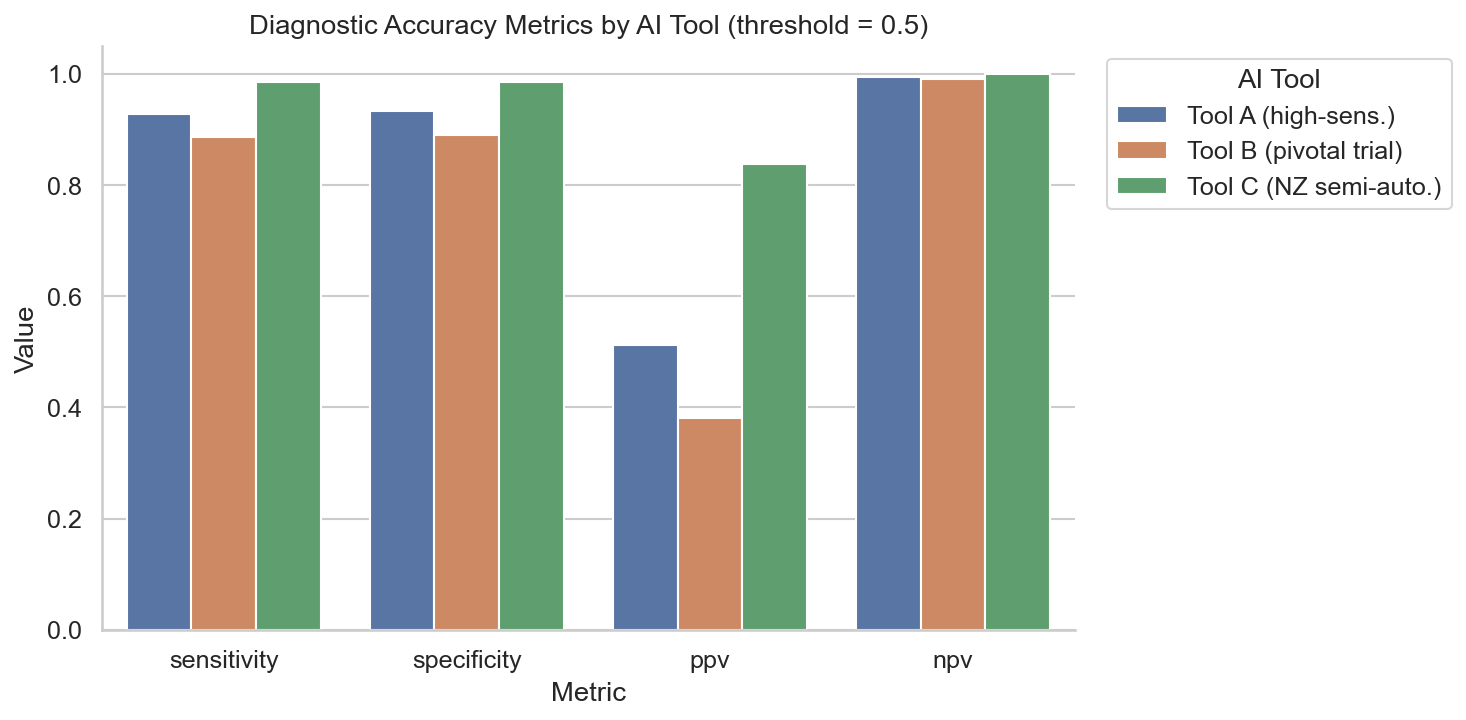

In [4]:
# Visualise as a grouped bar chart
metrics_to_plot = ["sensitivity", "specificity", "ppv", "npv"]
plot_data = acc_table.melt(id_vars="tool", value_vars=metrics_to_plot,
                           var_name="Metric", value_name="Value")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_data, x="Metric", y="Value", hue="tool", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Value")
ax.set_title("Diagnostic Accuracy Metrics by AI Tool (threshold = 0.5)")
ax.legend(title="AI Tool", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/figures/diagnostic_accuracy_bars.png")
plt.show()

## 3. ROC Analysis

Receiver Operating Characteristic curves show the trade-off between sensitivity
and false positive rate across all possible thresholds. The Area Under the Curve
(AUC) provides a threshold-independent measure of discriminative ability.

In [5]:
roc_results = {}
for name, df in tools.items():
    roc = roc_analysis(df["has_referable_dr"], df["ai_score"])
    roc_results[name] = roc
    print(f"{name}: AUC = {roc['auc']:.4f}")

Tool A (high-sens.): AUC = 0.9818
Tool B (pivotal trial): AUC = 0.9588
Tool C (NZ semi-auto.): AUC = 0.9991


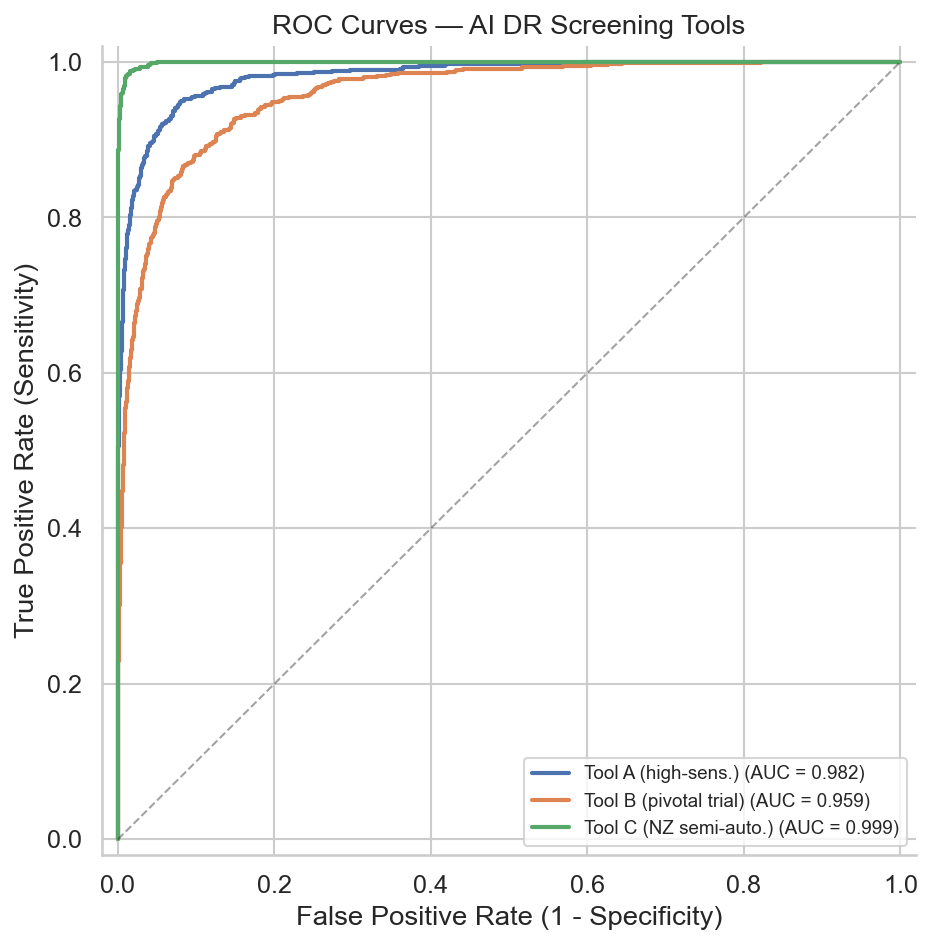

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_roc_curves(roc_results, title="ROC Curves — AI DR Screening Tools", ax=ax,
                save_path="../outputs/figures/roc_curves.png")
plt.show()

## 4. Precision-Recall Analysis

In low-prevalence screening settings, precision-recall curves can be more
informative than ROC curves because they highlight performance in the
positive class (which is the minority).

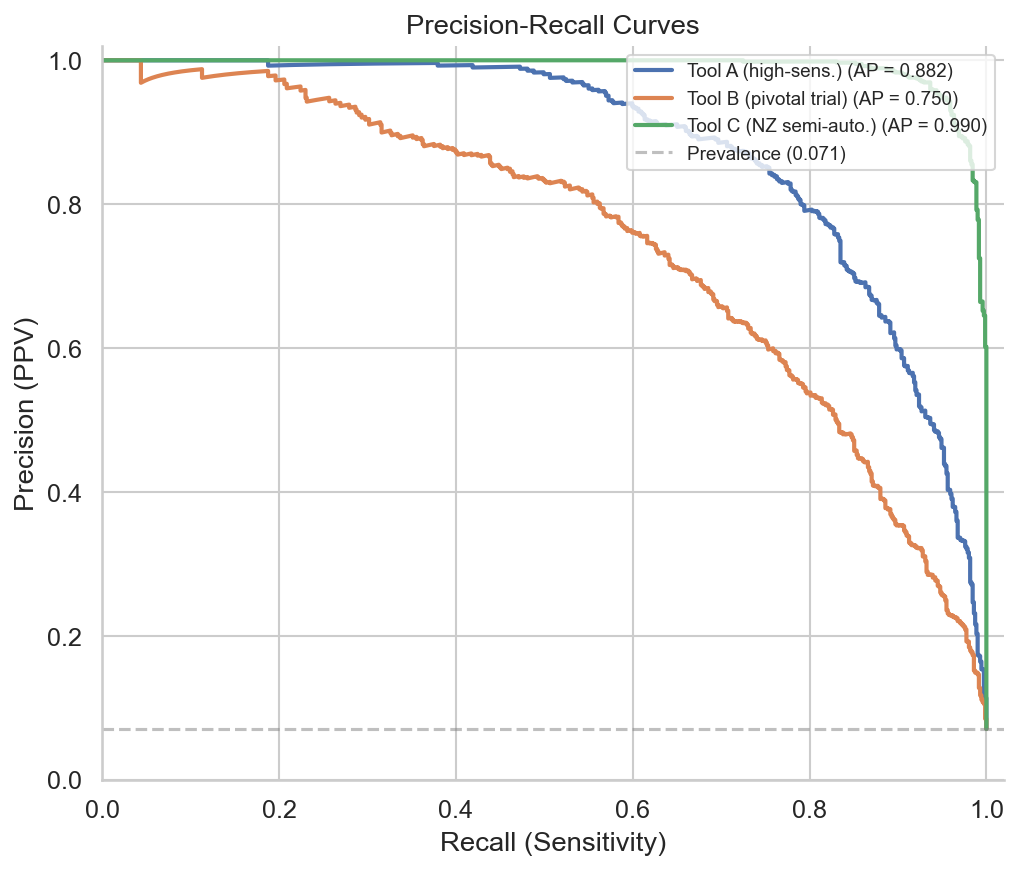

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, df in tools.items():
    pr = precision_recall_analysis(df["has_referable_dr"], df["ai_score"])
    ax.plot(pr["recall"], pr["precision"], label=f'{name} (AP = {pr["ap"]:.3f})', linewidth=2)

prevalence = list(tools.values())[0]["has_referable_dr"].mean()
ax.axhline(prevalence, color="grey", linestyle="--", alpha=0.5, label=f"Prevalence ({prevalence:.3f})")
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision (PPV)")
ax.set_title("Precision-Recall Curves")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("../outputs/figures/precision_recall.png")
plt.show()

## 5. Calibration Assessment

Calibration plots (reliability diagrams) show whether the predicted probabilities
match observed frequencies. A well-calibrated model's predictions of 0.7 should
correspond to ~70% actual positive rate. The Expected Calibration Error (ECE)
quantifies average miscalibration.

In [8]:
cal_results = {}
for name, df in tools.items():
    cal = calibration_analysis(df["has_referable_dr"], df["ai_score"], n_bins=10)
    cal_results[name] = cal
    print(f"{name}: ECE = {cal['ece']:.4f}")

Tool A (high-sens.): ECE = 0.1984
Tool B (pivotal trial): ECE = 0.2292
Tool C (NZ semi-auto.): ECE = 0.1320


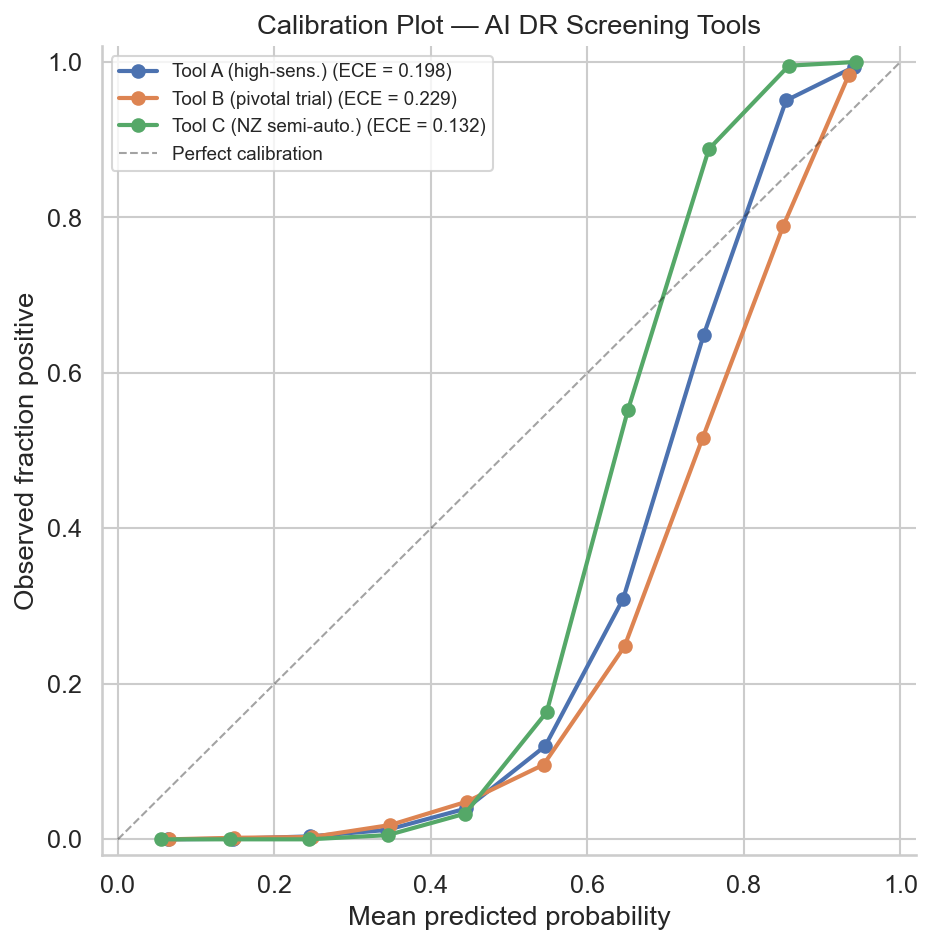

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_calibration(cal_results, title="Calibration Plot — AI DR Screening Tools", ax=ax,
                 save_path="../outputs/figures/calibration.png")
plt.show()

## 6. Optimal Operating Points

In screening contexts, it may be appropriate to choose a threshold that
maximises sensitivity (to avoid missing disease) even at the cost of some
specificity. We compare two threshold selection methods:

- **Youden's J** — maximises sensitivity + specificity - 1
- **Sensitivity floor (≥0.90)** — highest specificity achievable while maintaining ≥90% sensitivity

In [10]:
threshold_rows = []
for name, df in tools.items():
    for method in ["youden", "sensitivity_floor"]:
        opt = optimal_threshold(df["has_referable_dr"], df["ai_score"], method=method)
        opt["tool"] = name
        opt["method"] = method
        threshold_rows.append(opt)

thresh_table = pd.DataFrame(threshold_rows)[
    ["tool", "method", "threshold", "sensitivity", "specificity"]
]
print("Optimal operating points:")
print(thresh_table.to_string(index=False))

Optimal operating points:
                  tool            method  threshold  sensitivity  specificity
   Tool A (high-sens.)            youden   0.481860     0.946403     0.922506
   Tool A (high-sens.) sensitivity_floor   0.547460     0.901269     0.953934
Tool B (pivotal trial)            youden   0.536530     0.866008     0.916586
Tool B (pivotal trial) sensitivity_floor   0.479889     0.901269     0.874610
Tool C (NZ semi-auto.)            youden   0.489102     0.988717     0.984609
Tool C (NZ semi-auto.) sensitivity_floor   0.709035     0.904090     0.998816


## 7. Summary

| Metric | Tool A (high-sens.) | Tool B (pivotal) | Tool C (NZ semi-auto.) |
|--------|-------------------|-----------------|----------------------|
| Based on | Meta-analysis (Khan 2025) | FDA trial (Abramoff 2018) | NZ trial (Vaghefi 2022) |

Key observations:
- All three tools demonstrate strong discriminative ability (AUC > 0.85)
- Tool C (semi-automated, based on THEIA) achieves the highest AUC, consistent with its combined AI + human grader design
- Calibration varies across tools — an important consideration for clinical decision support
- The choice of operating threshold substantially affects the sensitivity-specificity trade-off

These results represent baseline performance assuming equal accuracy across
all demographic subgroups. In Notebook 3, we examine whether this assumption
holds and what the equity implications might be.